## 1. Veri ve Kütüphanelerin Yüklenmesi

In [33]:
# Kütüphaneler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [34]:
# Genel yuvarlama yardımcı fonksiyonu
def round_numeric(data, decimals=2):
    """
    Bir DataFrame'deki tüm sayısal (float) sütunları belirtilen ondalık basamağa yuvarlar.
    ID, flag, kategori gibi sütunlara dokunmaz.
    """
    result = data.copy()
    float_cols = result.select_dtypes(include=['float64', 'float32']).columns
    result[float_cols] = result[float_cols].round(decimals)
    return result

In [35]:
# Verinin yüklenmesi
df = pd.read_excel('/content/mv_insurance_data.xlsx', engine='openpyxl')

print(df.shape)
df.head()

(105555, 30)


,ID,Date_start_contract,Date_last_renewal,Date_next_renewal,Date_birth,Date_driving_licence,Distribution_channel,Seniority,Policies_in_force,Max_policies,Max_products,Lapse,Date_lapse,Payment,Premium,Cost_claims_year,N_claims_year,N_claims_history,R_Claims_history,Type_risk,Area,Second_driver,Year_matriculation,Power,Cylinder_capacity,Value_vehicle,N_doors,Type_fuel,Length,Weight
0,1,2015-11-05,2015-11-05,2016-11-05,1956-04-15,1976-03-20,0,4,1,2,1,0,NaT,0,22252,0,0,0,0,1,0,0,2004,80,599,7068,0,P,NaN,190
1,1,2015-11-05,2016-11-05,2017-11-05,1956-04-15,1976-03-20,0,4,1,2,1,0,NaT,0,21378,0,0,0,0,1,0,0,2004,80,599,7068,0,P,NaN,190
2,1,2015-11-05,2017-11-05,2018-11-05,1956-04-15,1976-03-20,0,4,2,2,1,0,NaT,0,21484,0,0,0,0,1,0,0,2004,80,599,7068,0,P,NaN,190
3,1,2015-11-05,2018-11-05,2019-11-05,1956-04-15,1976-03-20,0,4,2,2,1,0,NaT,0,21699,0,0,0,0,1,0,0,2004,80,599,7068,0,P,NaN,190
4,2,2017-09-26,2017-09-26,2018-09-26,1956-04-15,1976-03-20,0,4,2,2,1,0,NaT,1,2137,0,0,0,0,1,0,0,2004,80,599,7068,0,P,NaN,190


## 2. Keşifsel Veri Analizi ve Verileriin Düzenlenmesi

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105555 entries, 0 to 105554
Data columns (total 30 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   ID                    105555 non-null  int64         
 1   Date_start_contract   105555 non-null  datetime64[ns]
 2   Date_last_renewal     105555 non-null  datetime64[ns]
 3   Date_next_renewal     105555 non-null  datetime64[ns]
 4   Date_birth            105555 non-null  datetime64[ns]
 5   Date_driving_licence  105555 non-null  datetime64[ns]
 6   Distribution_channel  105555 non-null  int64         
 7   Seniority             105555 non-null  int64         
 8   Policies_in_force     105555 non-null  int64         
 9   Max_policies          105555 non-null  int64         
 10  Max_products          105555 non-null  int64         
 11  Lapse                 105555 non-null  int64         
 12  Date_lapse            35147 non-null   datetime64[ns]
 13 

In [37]:
# Eksik değer kontrolü
missing = df.isna().sum()
missing = missing[missing > 0]
print(missing)

# Date_lapse'in boş olması normal çünkü sadece iptal edilen poliçelerde dolu.
# Lapse == 0 olan satırlarda Date_lapse boş olmalı, kontrol edelim:
print(df.loc[df['Lapse'] == 0, 'Date_lapse'].notna().sum(), "adet tutarsızlık (0 olması beklenir)")

Date_lapse    70408
Type_fuel      1764
Length        10329
dtype: int64
15975 adet tutarsızlık (0 olması beklenir)


In [38]:
# Type_fuel ve Length eksiklerini doldurma
# Type_fuel: kategorik -> en sık görülen değer (mod) ile dolduruluyor
df['Type_fuel'] = df['Type_fuel'].fillna(df['Type_fuel'].mode()[0])

# Length: sayısal -> medyan ile dolduruluyor (aykırı değerlerden etkilenmez)
df['Length'] = df['Length'].fillna(df['Length'].median())

print(df[['Type_fuel', 'Length']].isna().sum())

Type_fuel    0
Length       0
dtype: int64


In [39]:
# Türetilmiş değişkenler
# Referans tarih olarak her satırın kendi yenileme tarihini kullanılıyor
df['Age'] = (df['Date_last_renewal'] - df['Date_birth']).dt.days // 365
df['Driving_experience'] = (df['Date_last_renewal'] - df['Date_driving_licence']).dt.days // 365
df['Vehicle_age'] = df['Date_last_renewal'].dt.year - df['Year_matriculation']
df['Contract_duration_days'] = (df['Date_last_renewal'] - df['Date_start_contract']).dt.days

# Mantık dışı değerleri kontrol et (negatif yaş, negatif deneyim vb.)
print("Negatif Age:", (df['Age'] < 0).sum())
print("Negatif Driving_experience:", (df['Driving_experience'] < 0).sum())
print("Negatif Vehicle_age:", (df['Vehicle_age'] < 0).sum())

Negatif Age: 0
Negatif Driving_experience: 31
Negatif Vehicle_age: 0


In [40]:
#  Mantık dışı satırları temizleme
df = df[(df['Driving_experience'] >= 0) ]
print("Temizlik sonrası boyut:", df.shape)

Temizlik sonrası boyut: (105524, 34)


In [41]:
# ID + tarih bazında sıralama (panel/zaman serisi yapısını netleştirme)
df = df.sort_values(['ID', 'Date_last_renewal']).reset_index(drop=True)

# Rapor dönemi için yıl kolonu (çeyreklik pipeline'da kullanılacak)
df['Report_period_Q'] = df['Date_last_renewal'].dt.to_period('Q')

df[['ID', 'Date_last_renewal', 'Report_period_Q']].head()

,ID,Date_last_renewal,Report_period_Q
0,1,2015-11-05,2015Q4
1,1,2016-11-05,2016Q4
2,1,2017-11-05,2017Q4
3,1,2018-11-05,2018Q4
4,2,2017-09-26,2017Q3


In [42]:
# Hasar tipi verisi
claims_type = pd.read_excel('/content/sample_type_claim.xlsx', engine='openpyxl')

claims_summary = claims_type.groupby('ID').agg(
    total_claim_cost_by_type=('Cost_claims_by_type', 'sum'),
    n_claim_records=('Claims_type', 'count'),
    dominant_claim_type=('Claims_type', lambda x: x.mode()[0])
).reset_index()

claims_summary.head()

,ID,total_claim_cost_by_type,n_claim_records,dominant_claim_type
0,28,33202,1,complaint
1,36,5735,1,travel assistance
2,42,575,1,travel assistance
3,60,13890,2,travel assistance
4,77,157493,1,complaint


In [43]:
# Temizlenmiş veriyi kaydetme (bir sonraki aşamada kullanacağız)
df.to_csv('cleaned_motor_insurance.csv', index=False)
claims_summary.to_csv('claims_type_summary.csv', index=False)

from google.colab import files
files.download('cleaned_motor_insurance.csv')
files.download('claims_type_summary.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 3. Verinin İstatistiksel İncelenmesi

In [44]:
# Sayısal değişkenler için betimsel istatistikler
numeric_cols = ['Premium', 'Cost_claims_year', 'N_claims_year', 'N_claims_history',
                 'R_Claims_history', 'Power', 'Cylinder_capacity', 'Value_vehicle',
                 'Length', 'Weight', 'Age', 'Driving_experience', 'Vehicle_age']

desc = df[numeric_cols].describe().T
desc['skew'] = df[numeric_cols].skew()
desc['kurtosis'] = df[numeric_cols].kurt()
desc

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
Premium,105524.0,28648.598859,15900.227003,41.000,21892.00,28026.00,35135.000,2.993340e+05,1.311788,7.615078
Cost_claims_year,105524.0,12341.555163,144558.579297,0.000,0.00,0.00,0.000,2.608532e+07,109.583812,17540.385398
N_claims_year,105524.0,0.394659,1.105042,0.000,0.00,0.00,0.000,2.500000e+01,4.694144,33.797666
N_claims_history,105524.0,2.752075,3.882012,0.000,0.00,1.00,4.000,5.200000e+01,2.913653,14.780026
R_Claims_history,105524.0,28.798633,60.544785,0.000,0.00,1.00,33.000,2.607000e+03,5.450997,102.487840
Power,105524.0,92.690336,37.006421,0.000,75.00,90.00,110.000,5.800000e+02,0.452925,5.845082
Cylinder_capacity,105524.0,1617.917791,604.563126,49.000,1390.00,1598.00,1910.000,7.480000e+03,0.270829,5.974771
Value_vehicle,105524.0,462241.495186,883167.194629,656.000,15855.00,21970.00,262218.000,1.402000e+07,2.488406,9.299430
Length,105524.0,4.249847,0.373571,1.978,4.03,4.23,4.419,8.218000e+00,1.306019,6.645077
Weight,105524.0,1191.389248,457.972880,43.000,1043.00,1205.00,1388.000,7.300000e+03,1.244956,15.242083


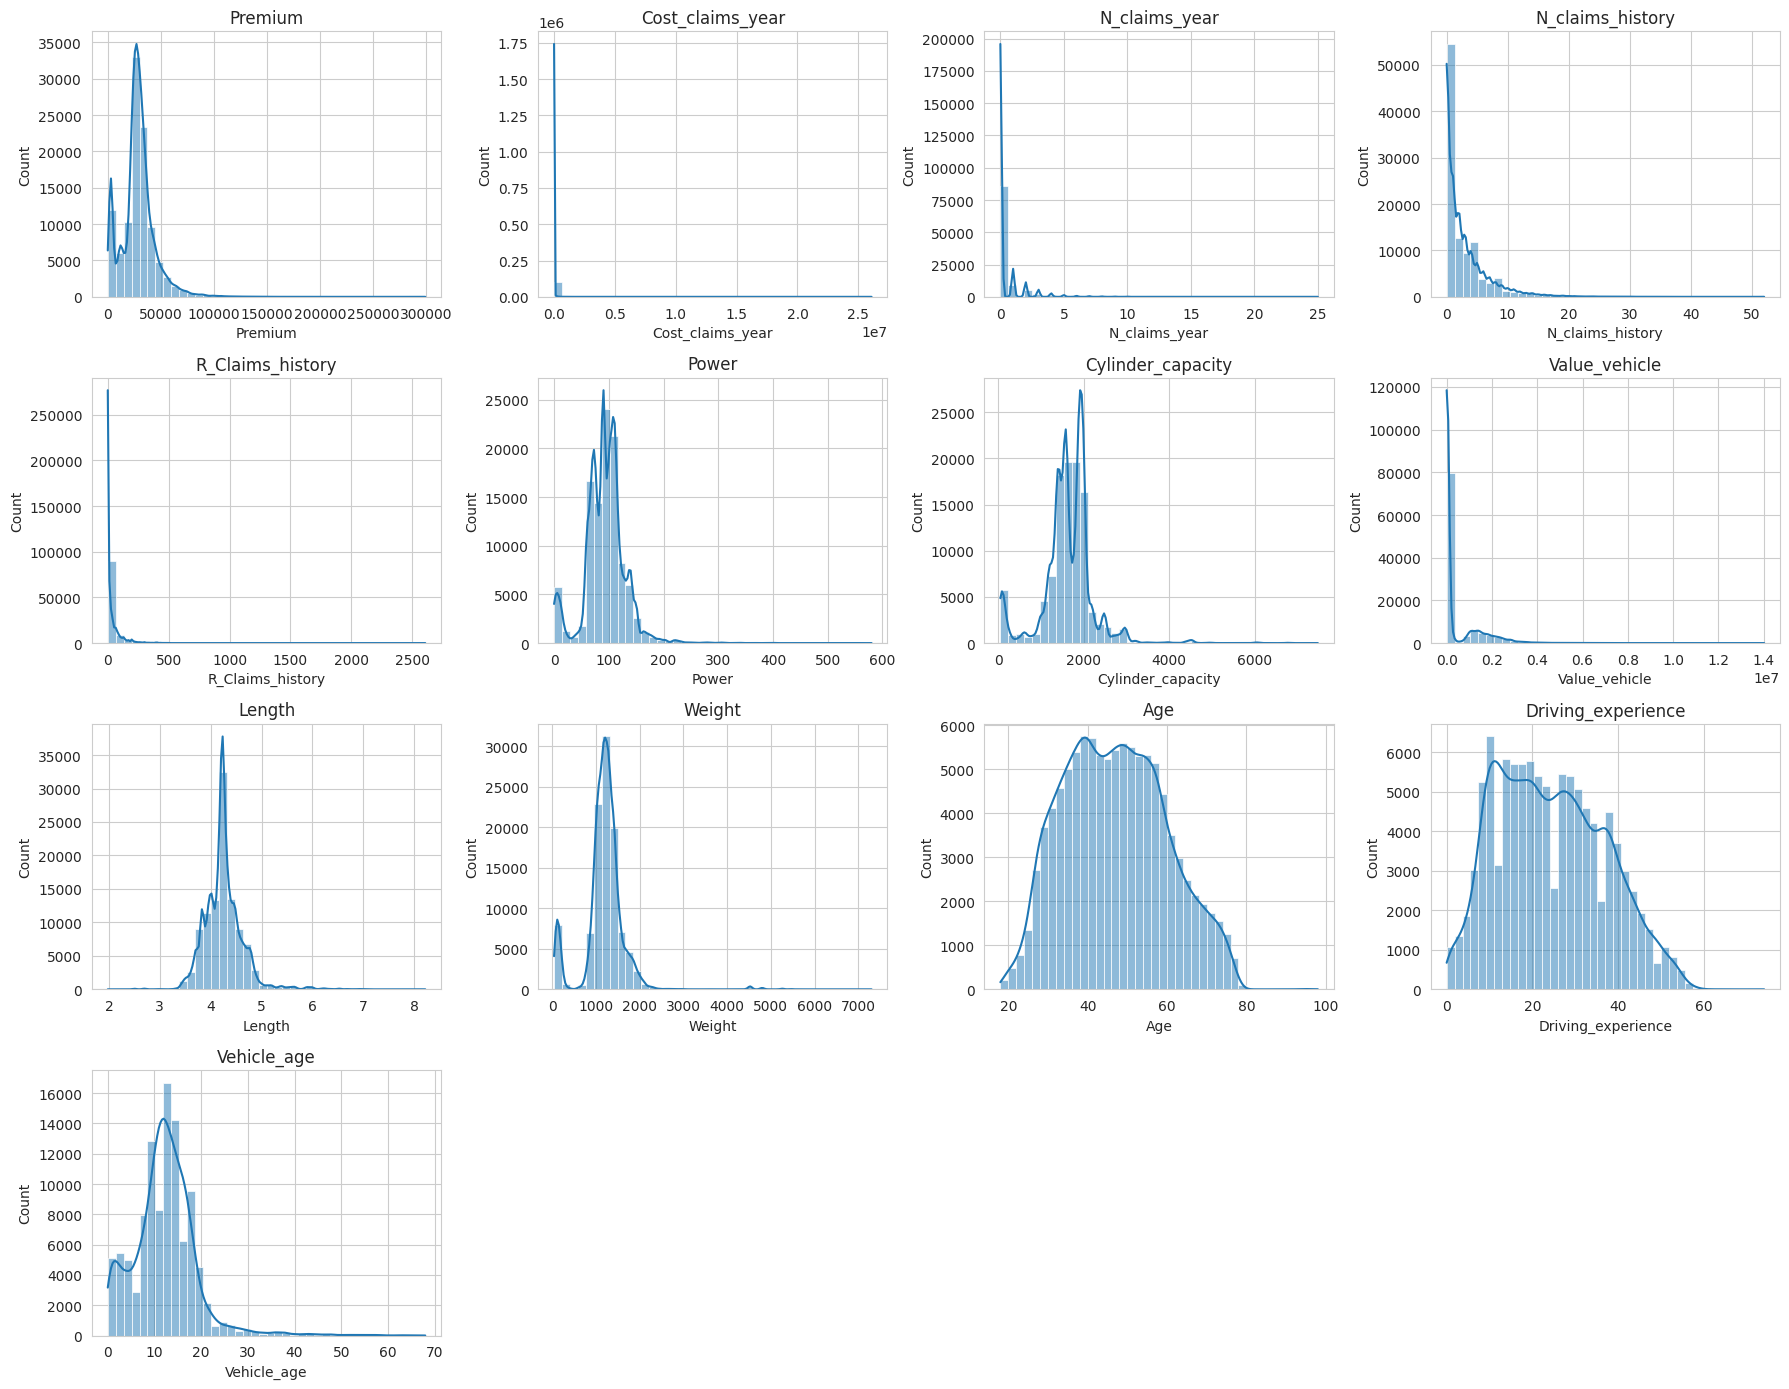

In [45]:
# Dağılım histogramları

sns.set_style('whitegrid')

fig, axes = plt.subplots(4, 4, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], bins=40)
    axes[i].set_title(col)

for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [46]:
# Normallik testi (D'Agostino-Pearson)
# Not: Shapiro-Wilk 5000 satır üstünde güvenilir çalışmaz, bu yüzden D'Agostino kullanılıyor
from scipy import stats

normality_results = []
for col in numeric_cols:
    stat, p = stats.normaltest(df[col].dropna())
    normality_results.append({
        'variable': col,
        'p_value': p,
        'normal_mi': 'Hayır' if p < 0.05 else 'Evet'
    })

pd.DataFrame(normality_results)

,variable,p_value,normal_mi
0,Premium,0.0,Hayır
1,Cost_claims_year,0.0,Hayır
2,N_claims_year,0.0,Hayır
3,N_claims_history,0.0,Hayır
4,R_Claims_history,0.0,Hayır
5,Power,0.0,Hayır
6,Cylinder_capacity,0.0,Hayır
7,Value_vehicle,0.0,Hayır
8,Length,0.0,Hayır
9,Weight,0.0,Hayır


In [47]:
# Aykırı değer (outlier) tespiti - IQR yöntemi
outlier_summary = []
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary.append({
        'variable': col,
        'n_outliers': n_outliers,
        'pct_outliers': round(n_outliers / len(df) * 100, 2)
    })

pd.DataFrame(outlier_summary).sort_values('pct_outliers', ascending=False)

,variable,n_outliers,pct_outliers
7,Value_vehicle,25162,23.84
2,N_claims_year,19636,18.61
1,Cost_claims_year,19636,18.61
4,R_Claims_history,11733,11.12
9,Weight,11544,10.94
6,Cylinder_capacity,10737,10.17
5,Power,9681,9.17
0,Premium,7750,7.34
3,N_claims_history,5013,4.75
8,Length,3371,3.19


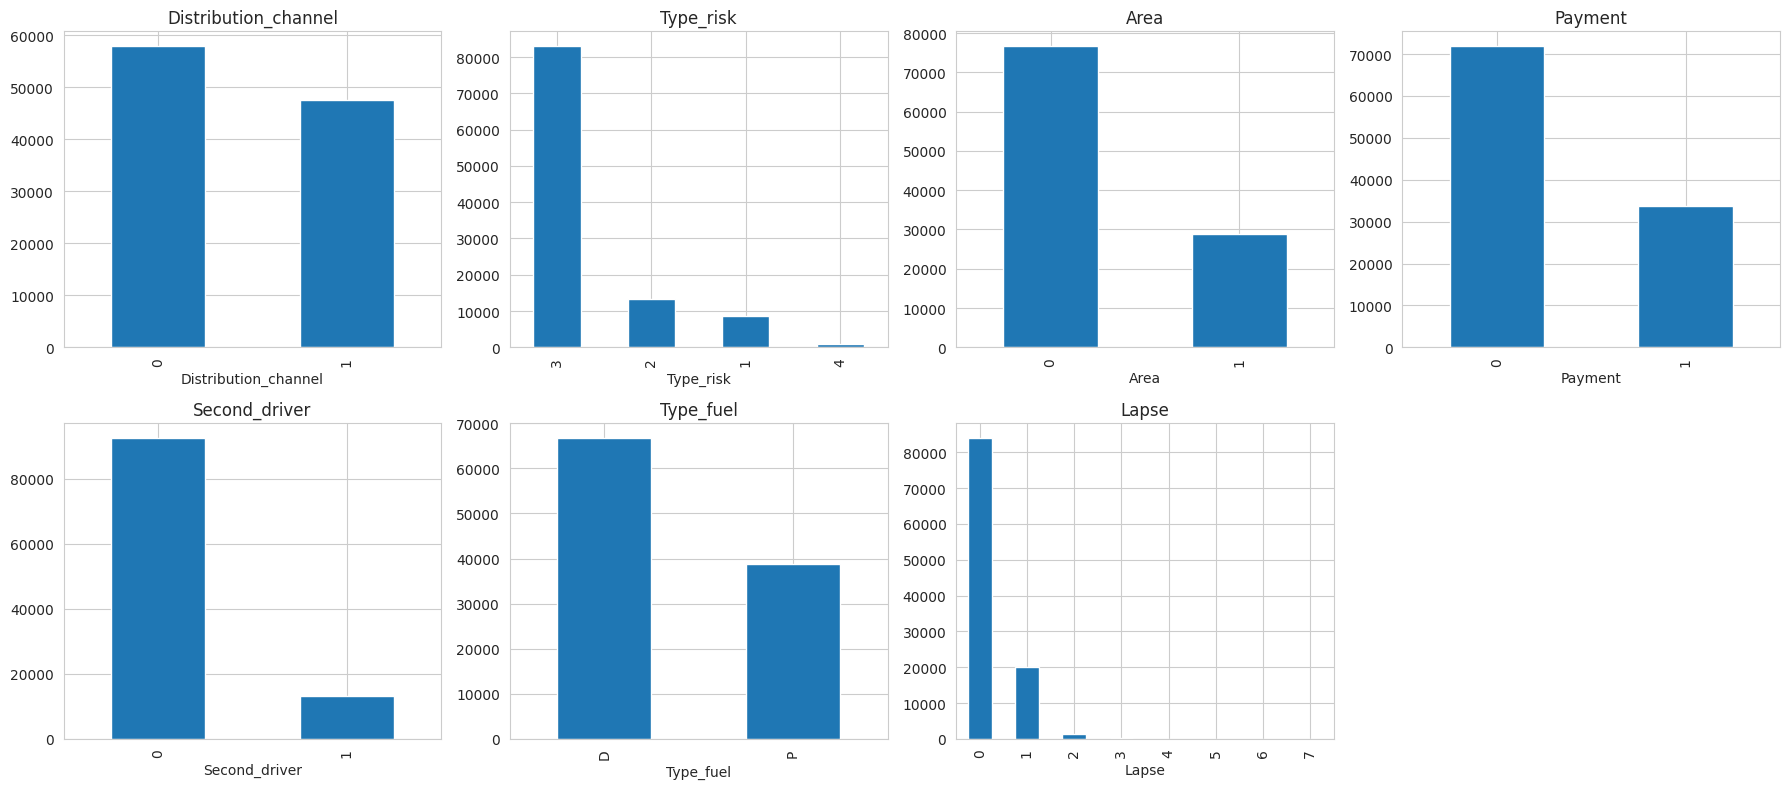

In [48]:
# Kategorik değişkenlerin dağılımı
categorical_cols = ['Distribution_channel', 'Type_risk', 'Area', 'Payment',
                     'Second_driver', 'Type_fuel', 'Lapse']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    df[col].value_counts().plot(kind='bar', ax=axes[i])
    axes[i].set_title(col)

for j in range(len(categorical_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

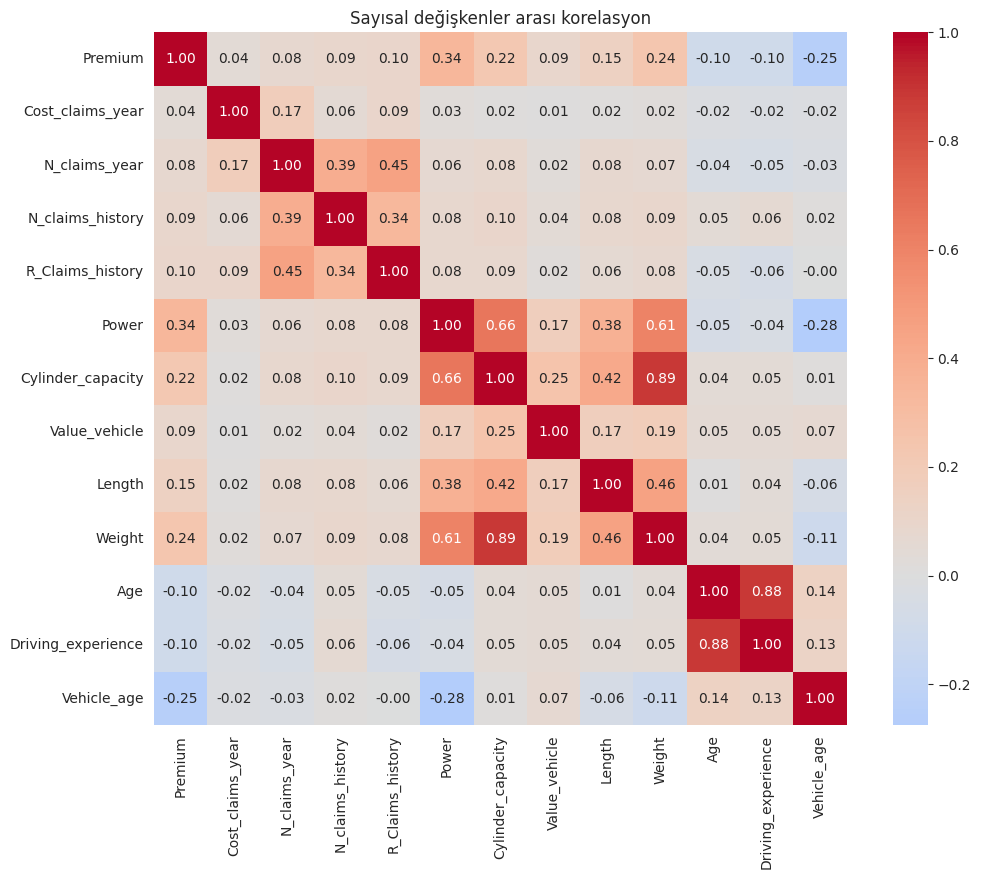

In [49]:
# Korelasyon matrisi (sayısal değişkenler arası)
plt.figure(figsize=(12, 9))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Sayısal değişkenler arası korelasyon')
plt.show()

In [50]:
# Cost_claims_year ve Value_vehicle'daki en uç değerleri inceleme
print("=== En yüksek 15 Cost_claims_year ===")
print(df.nlargest(15, 'Cost_claims_year')[['ID', 'Date_last_renewal', 'Premium',
                                              'Cost_claims_year', 'N_claims_year', 'Type_risk']])

print("\n=== En yüksek 15 Value_vehicle ===")
print(df.nlargest(15, 'Value_vehicle')[['ID', 'Type_risk', 'Value_vehicle', 'Power', 'Year_matriculation']])

=== En yüksek 15 Cost_claims_year ===
           ID Date_last_renewal  Premium  Cost_claims_year  N_claims_year  \
55141   27326        2016-09-13    62376          26085324              3   
63262   31466        2017-03-29    22057          23628518              2   
95787   48099        2016-05-01     3594          12880973              3   
92937   46596        2016-08-05    74241           7196887              3   
44035   21404        2016-06-10    47803           5965665              3   
60853   30233        2015-11-24    34166           5010194              5   
69093   34467        2015-12-05    58863           4854677              4   
48895   24000        2016-09-26    36745           4065848              3   
55187   27351        2017-10-16    30769           3746928              1   
74368   37246        2016-02-06    29214           3637581              4   
8483     4164        2017-02-15    38921           3601352              4   
104241  52751        2016-12-07     55

In [51]:
# Yüzdelik dilimlerle uç noktaları netleştirme
for col in ['Cost_claims_year', 'Value_vehicle']:
    print(f"\n{col} yüzdelikler:")
    print(df[col].quantile([0.90, 0.95, 0.99, 0.995, 0.999, 1.0]))


Cost_claims_year yüzdelikler:
0.900    1.225900e+04
0.950    4.653440e+04
0.990    2.374984e+05
0.995    4.166932e+05
0.999    1.085231e+06
1.000    2.608532e+07
Name: Cost_claims_year, dtype: float64

Value_vehicle yüzdelikler:
0.900     1800923.0
0.950     2343947.0
0.990     3556795.0
0.995     4213623.0
0.999     5946516.0
1.000    14019999.0
Name: Value_vehicle, dtype: float64


In [52]:
#  Uç değerleri silmek yerine flag'leyip winsorize etme
# Mantık: bu satırlar gerçek olabilir, silersek bilgi kaybederiz.
# Ama KPI/anomali hesaplarını bozmasınlar diye "ham" ve "işlenmiş" versiyonu ayrı tutuyoruz.

# 1. Şüpheli/uç satırları ayrı flag ile işaretle (rapor için saklıyoruz, silmiyoruz)
df['flag_extreme_claim'] = df['Cost_claims_year'] > df['Cost_claims_year'].quantile(0.999)
df['flag_extreme_value'] = df['Value_vehicle'] > df['Value_vehicle'].quantile(0.999)

print("Extreme claim flag:", df['flag_extreme_claim'].sum())
print("Extreme value flag:", df['flag_extreme_value'].sum())

Extreme claim flag: 106
Extreme value flag: 102


In [53]:
#  Winsorize edilmiş (kırpılmış) yeni sütunlar oluşturma
# Orijinal sütunlar korunuyor, istatistiksel hesaplarda _capped versiyonu kullanacağız
def winsorize_col(series, lower_q=0.01, upper_q=0.99):
    lower = series.quantile(lower_q)
    upper = series.quantile(upper_q)
    return series.clip(lower, upper)

df['Cost_claims_year_capped'] = winsorize_col(df['Cost_claims_year'])
df['Value_vehicle_capped'] = winsorize_col(df['Value_vehicle'])

# Karşılaştırma
print(df[['Cost_claims_year', 'Cost_claims_year_capped']].describe())
print(df[['Value_vehicle', 'Value_vehicle_capped']].describe())

       Cost_claims_year  Cost_claims_year_capped
count      1.055240e+05            105524.000000
mean       1.234156e+04              8057.616799
std        1.445586e+05             31887.093342
min        0.000000e+00                 0.000000
25%        0.000000e+00                 0.000000
50%        0.000000e+00                 0.000000
75%        0.000000e+00                 0.000000
max        2.608532e+07            237498.430000
       Value_vehicle  Value_vehicle_capped
count   1.055240e+05          1.055240e+05
mean    4.622415e+05          4.519712e+05
std     8.831672e+05          8.312226e+05
min     6.560000e+02          1.933600e+03
25%     1.585500e+04          1.585500e+04
50%     2.197000e+04          2.197000e+04
75%     2.622180e+05          2.622180e+05
max     1.402000e+07          3.556795e+06


In [54]:
#  Log dönüşümü (zero-inflated değişkenler için, ileride KPI/anomali aşamasında kullanacağız)
df['Cost_claims_year_log'] = np.log1p(df['Cost_claims_year'])
df['Value_vehicle_log'] = np.log1p(df['Value_vehicle'])
df['Premium_log'] = np.log1p(df['Premium'])

df[['Cost_claims_year_log', 'Value_vehicle_log', 'Premium_log']].describe()

,Cost_claims_year_log,Value_vehicle_log,Premium_log
count,105524.000000,105524.000000,105524.000000
mean,1.795678,10.941756,10.010356
std,3.827143,2.044161,0.912798
min,0.000000,6.487684,3.737670
25%,0.000000,9.671303,9.993922
50%,0.000000,9.997479,10.240924
75%,0.000000,12.476935,10.466982
max,17.076883,16.455995,12.609319


In [55]:
df.head()

,ID,Date_start_contract,Date_last_renewal,Date_next_renewal,Date_birth,Date_driving_licence,Distribution_channel,Seniority,Policies_in_force,Max_policies,Max_products,Lapse,Date_lapse,Payment,Premium,Cost_claims_year,N_claims_year,N_claims_history,R_Claims_history,Type_risk,Area,Second_driver,Year_matriculation,Power,Cylinder_capacity,Value_vehicle,N_doors,Type_fuel,Length,Weight,Age,Driving_experience,Vehicle_age,Contract_duration_days,Report_period_Q,flag_extreme_claim,flag_extreme_value,Cost_claims_year_capped,Value_vehicle_capped,Cost_claims_year_log,Value_vehicle_log,Premium_log
0,1,2015-11-05,2015-11-05,2016-11-05,1956-04-15,1976-03-20,0,4,1,2,1,0,NaT,0,22252,0,0,0,0,1,0,0,2004,80,599,7068,0,P,4.23,190,59,39,11,0,2015Q4,False,False,0.0,7068.0,0.0,8.863474,10.010232
1,1,2015-11-05,2016-11-05,2017-11-05,1956-04-15,1976-03-20,0,4,1,2,1,0,NaT,0,21378,0,0,0,0,1,0,0,2004,80,599,7068,0,P,4.23,190,60,40,12,366,2016Q4,False,False,0.0,7068.0,0.0,8.863474,9.970164
2,1,2015-11-05,2017-11-05,2018-11-05,1956-04-15,1976-03-20,0,4,2,2,1,0,NaT,0,21484,0,0,0,0,1,0,0,2004,80,599,7068,0,P,4.23,190,61,41,13,731,2017Q4,False,False,0.0,7068.0,0.0,8.863474,9.975110
3,1,2015-11-05,2018-11-05,2019-11-05,1956-04-15,1976-03-20,0,4,2,2,1,0,NaT,0,21699,0,0,0,0,1,0,0,2004,80,599,7068,0,P,4.23,190,62,42,14,1096,2018Q4,False,False,0.0,7068.0,0.0,8.863474,9.985068
4,2,2017-09-26,2017-09-26,2018-09-26,1956-04-15,1976-03-20,0,4,2,2,1,0,NaT,1,2137,0,0,0,0,1,0,0,2004,80,599,7068,0,P,4.23,190,61,41,13,0,2017Q3,False,False,0.0,7068.0,0.0,8.863474,7.667626


In [56]:
# 1. aşamayı kapatan final veri kaydı
df.to_csv('cleaned_motor_insurance_final.csv', index=False)
claims_summary.to_csv('claims_type_summary.csv', index=False)

from google.colab import files
files.download('cleaned_motor_insurance_final.csv')
files.download('claims_type_summary.csv')

print("Final shape:", df.shape)
print("Toplam sütun sayısı:", df.shape[1])

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Final shape: (105524, 42)
Toplam sütun sayısı: 42


# 4. İstatistiksel İncelemenin Sonucu

## İstatistiksel İnceleme Sonucu

### Veri Seti Hakkında
Bu proje, 105.555 satırlık bir motorlu taşıt sigortası poliçe portföyünü kapsamaktadır.
Veri, panel (zaman serisi) yapısındadır — her poliçe sahibi (ID), farklı yıllara ait
birden fazla yenileme kaydına sahiptir. 30 orijinal değişkene ek olarak, analiz
için yaş, sürüş deneyimi, araç yaşı ve sözleşme süresi gibi türetilmiş değişkenler
eklenmiştir.

### Veri Temizleme Sürecinde Yapılanlar
- Tarih sütunları datetime formatına çevrildi.
- `Type_fuel` (1.764 eksik) ve `Length` (10.329 eksik) sütunlarındaki boşluklar
  sırasıyla mod ve medyan ile dolduruldu.
- `Date_lapse` sütunundaki boşluklar normal karşılandı, çünkü bu alan yalnızca
  iptal edilen poliçelerde doludur.
- Negatif sürüş deneyimi gibi mantık dışı 31 satır veri setinden çıkarıldı.

### Dağılım Analizi Bulguları
- **13 sayısal değişkenin tamamı istatistiksel olarak normal dağılmamaktadır**
  (D'Agostino-Pearson testi, tüm değişkenlerde p < 0.05). Bu, ileride yapılacak
  anomali tespitinde klasik z-score yerine dağılımdan bağımsız yöntemlerin
  (IQR, log-dönüşüm, Isolation Forest) tercih edilmesi gerektiğini göstermektedir.
- `Cost_claims_year`, `N_claims_year` ve `Value_vehicle` gibi değişkenler
  **zero-inflated** yapıdadır — poliçelerin büyük çoğunluğunda değer sıfıra
  yakınken, az sayıda poliçede çok yüksek değerler görülmektedir. Bu değişkenlerin
  skewness/kurtosis değerleri aşırı yüksektir (örn. Cost_claims_year skew: 109.6).
- IQR yöntemiyle hesaplanan aykırı değer oranları, zero-inflated değişkenlerde
  yanıltıcı derecede yüksek çıkmıştır (örn. Value_vehicle %23.84, Cost_claims_year
  %18.61) — bu, klasik IQR'ın bu tip dağılımlarda tek başına yeterli olmadığını
  doğrulamaktadır.

### Uç Değerlerin İncelenmesi
- `Cost_claims_year` ve `Value_vehicle` değişkenlerindeki en yüksek gözlemler
  incelenmiş; bu değerlerin veri hatasından çok gerçek fakat nadir olaylara
  (yüksek hasar maliyetli poliçeler, yüksek segment/lüks araçlar) işaret ettiği
  görülmüştür. Örneğin en yüksek Value_vehicle gözlemleri, yüksek beygir gücü
  (300+ HP) değerleriyle tutarlıdır.
- Yüzdelik dilim analizi, her iki değişkende de %99'a kadar tutarlı bir artış
  olduğunu, ancak %99.9'dan sonra maksimuma doğru sert bir sıçrama yaşandığını
  göstermiştir. Bu nedenle uç değerler silinmemiş, ayrı bir flag (`flag_extreme_claim`,
  `flag_extreme_value`) ile işaretlenerek veri setinde korunmuştur.

### Değişkenler Arası İlişkiler
- `Cylinder_capacity`-`Weight` (r=0.89) ve `Age`-`Driving_experience` (r=0.88)
  arasında yüksek korelasyon tespit edilmiştir. Bu durum, ileride yapılacak
  segmentasyon (kümeleme) analizinde çoklu doğrusal bağlantı (multicollinearity)
  sorununa yol açabileceğinden, ilgili aşamada değişken seçimi veya PCA
  uygulanması planlanmaktadır.
- `Cost_claims_year` hiçbir değişkenle güçlü korelasyon göstermemektedir
  (en yüksek ilişki N_claims_year ile r=0.17), bu da hasar maliyetinin büyük
  ölçüde araç/sürücü özelliklerinden bağımsız, rastgele/nadir olaylarla
  belirlendiğine işaret etmektedir.

### Sonuç
Bu bulgular ışığında, ilerleyen KPI hesaplama ve anomali tespiti aşamalarında
dağılımdan bağımsız (robust) yöntemlerin kullanılmasına, segmentasyon aşamasında
ise yüksek korelasyonlu değişkenlerin ayrıca ele alınmasına karar verilmiştir.